# DBWFB2 STL-10 Reproducibility Notebook
## Hardware-matched protocol with software/hardware-matched DBWFB2 preprocessing

This notebook implements the **final hardware-matched experiment structure**:
fixed 1,600/400 train/validation split, untouched 3,200-image independent test set,
five prespecified seeds, separate Float and deployment-trained CNNs, validation-only
calibration, true-INT8 inference, native-resolution control, and hardware export files.

The DBWFB2 preprocessing path is defined as follows:

- The **Float DBWFB2 control** uses the same causal phase and the same
  **trailing-edge replicate boundary convention** as the implemented controller,
  but retains floating DBWFB2 coefficients.
- The **deployment / true-INT8 DBWFB2 path** uses the RTL structural model:
  integer coefficients `[27,-17,-78,273,614,273,-78,-17,27]`,
  arithmetic `>>> 10` after each 1-D pass, even-index decimation, and
  trailing-edge replicate extension.
- The centered zero-extension software convention is retained **only as a
  diagnostic comparator**, never as the primary deployment reference.

The deployment choices were frozen before independent-test evaluation:
gain 1 and deployment seeds Full=777, AvgPool=42, Haar=42, DBWFB2=42.
They are not reselected from the independent test set. The gain-2 run remains
a validation-only diagnostic.

The notebook does **not** hard-code reported accuracies or FPGA prediction
results. Run it top-to-bottom in a clean Colab runtime. Any numerical values
produced by this hardware-matched protocol must be used consistently in the public
result files.

Full intermediate preprocessing equivalence should be claimed only if an actual FPGA
64x64 LL dump is supplied and the optional comparison cell reports exact equality.


In [1]:
# 1. Imports and deterministic environment
import os, json, math, random, tarfile, urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from scipy import ndimage, stats
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

os.environ['TF_DETERMINISTIC_OPS'] = '1'
try:
    tf.config.experimental.enable_op_determinism()
except Exception as e:
    print('Determinism warning:', e)

print('TensorFlow:', tf.__version__)
print('GPU(s):', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU(s): [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# 2. Configuration: frozen before the final run
PROTOCOL_VERSION = "STL10_HW_MATCHED_DEPLOYMENT_V1"

CLASS_NAMES = ['airplane', 'car', 'dog', 'ship']
TARGET_IDXS = [0, 2, 5, 8]
NUM_CLASSES = 4

NUM_EPOCHS = 100
BATCH_SIZE = 32
FIR_BATCH = 64
SEEDS = [42, 100, 123, 777, 2024]

SPLIT_SEED = 20260821
BOARD500_SEED = 20260822
EQUIV_MARGIN_PP = 1.0
ALPHA = 0.05

ARMS = ['full', 'avgpool', 'haar', 'dbwfb2']
DISPLAY = {
    'full':'Full CNN (128x128)',
    'avgpool':'AvgPool (64x64)',
    'haar':'Aligned Haar LL (64x64)',
    'dbwfb2':'DBWFB2-9/7 LL (64x64)'
}

# Keep the hardware-matched deployment decisions frozen a priori.
SELECTED_INPUT_GAIN = 1
FROZEN_DEPLOYMENT_SEED_BY_ARM = {
    'full': 777,
    'avgpool': 42,
    'haar': 42,
    'dbwfb2': 42,
}

# Gain 2 is retained only as the validation-only diagnostic.
GAIN_CANDIDATES = [1, 2]
GAIN_ABLATION_SEEDS = SEEDS

RUN_NATIVE_96_48 = True
N_DIAGNOSTIC = 16

ROOT = Path('.')
RESULTS = ROOT / 'dbwfb2_hw_matched_outputs'
MODELS = RESULTS / 'models'
PKGS = RESULTS / 'int8_packages'
HWPKG = RESULTS / 'hardware_packages'
for p in [RESULTS, MODELS, PKGS, HWPKG]:
    p.mkdir(parents=True, exist_ok=True)

STL10_URL = 'https://ai.stanford.edu/~acoates/stl10/stl10_binary.tar.gz'
STL10_DIR = ROOT / 'stl10_binary'

print('Protocol:', PROTOCOL_VERSION)
print('Results directory:', RESULTS.resolve())
print('Seeds:', SEEDS)
print('Frozen deployment gain:', SELECTED_INPUT_GAIN)
print('Frozen deployment seeds:', FROZEN_DEPLOYMENT_SEED_BY_ARM)
print('Prespecified TOST margin:', EQUIV_MARGIN_PP, 'pp')


Protocol: STL10_HW_MATCHED_DEPLOYMENT_V1
Results directory: /content/dbwfb2_hw_matched_outputs
Seeds: [42, 100, 123, 777, 2024]
Frozen deployment gain: 1
Frozen deployment seeds: {'full': 777, 'avgpool': 42, 'haar': 42, 'dbwfb2': 42}
Prespecified TOST margin: 1.0 pp


In [3]:
# 3. Load STL-10 and preserve native 96x96 grayscale images
if not STL10_DIR.exists():
    print('Downloading STL-10...')
    urllib.request.urlretrieve(STL10_URL, 'stl10.tar.gz')
    with tarfile.open('stl10.tar.gz') as t:
        t.extractall('.')

def load_stl10_split(x_path, y_path):
    with open(x_path, 'rb') as f:
        data = np.frombuffer(f.read(), dtype=np.uint8)

    images = data.reshape(-1, 3, 96, 96).transpose(0, 3, 2, 1)
    with open(y_path, 'rb') as f:
        labels = np.frombuffer(f.read(), dtype=np.uint8) - 1
    return images, labels

def subset_four_classes(images, labels):
    src = np.flatnonzero(np.isin(labels, TARGET_IDXS))
    imgs = images[src]
    old = labels[src]
    remap = {old_id:new_id for new_id, old_id in enumerate(TARGET_IDXS)}
    y = np.array([remap[int(v)] for v in old], dtype=np.int32)
    gray = (0.2989*imgs[...,0] + 0.5870*imgs[...,1] + 0.1140*imgs[...,2]).astype(np.float32)
    return gray, y, src.astype(np.int32)

tr_rgb, tr_y_raw = load_stl10_split(STL10_DIR/'train_X.bin', STL10_DIR/'train_y.bin')
te_rgb, te_y_raw = load_stl10_split(STL10_DIR/'test_X.bin', STL10_DIR/'test_y.bin')

X_train96_all, y_train_all, train_source_idx = subset_four_classes(tr_rgb, tr_y_raw)
X_test96, y_test, test_source_idx = subset_four_classes(te_rgb, te_y_raw)

assert X_train96_all.shape == (2000,96,96)
assert X_test96.shape == (3200,96,96)
assert np.all(np.bincount(y_train_all) == 500)
assert np.all(np.bincount(y_test) == 800)

print('Official four-class train:', X_train96_all.shape, np.bincount(y_train_all))
print('Official four-class test :', X_test96.shape, np.bincount(y_test))

/tmp/ipykernel_4421/1855889150.py:6: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  t.extractall('.')


Official four-class train: (2000, 96, 96) [500 500 500 500]
Official four-class test : (3200, 96, 96) [800 800 800 800]


In [4]:
# 4. Define train/validation and board-500 indices BEFORE any training
idx_all = np.arange(len(y_train_all))
train_idx, val_idx = train_test_split(
    idx_all,
    test_size=0.20,
    random_state=SPLIT_SEED,
    shuffle=True,
    stratify=y_train_all
)

X_train96, y_train = X_train96_all[train_idx], y_train_all[train_idx]
X_val96, y_val = X_train96_all[val_idx], y_train_all[val_idx]

assert len(y_train) == 1600 and len(y_val) == 400
assert np.all(np.bincount(y_train) == 400)
assert np.all(np.bincount(y_val) == 100)


rng = np.random.default_rng(BOARD500_SEED)
board_idx = []
for c in range(NUM_CLASSES):
    candidates = np.flatnonzero(y_test == c)
    board_idx.extend(rng.choice(candidates, 125, replace=False).tolist())
board_idx = np.asarray(board_idx, dtype=np.int32)
rng.shuffle(board_idx)
assert np.all(np.bincount(y_test[board_idx]) == 125)

manifest = {
    'split_seed': SPLIT_SEED,
    'board500_seed': BOARD500_SEED,
    'train_indices_within_fourclass_train': train_idx.tolist(),
    'validation_indices_within_fourclass_train': val_idx.tolist(),
    'train_source_stl10_indices': train_source_idx[train_idx].tolist(),
    'validation_source_stl10_indices': train_source_idx[val_idx].tolist(),
    'board500_indices_within_fourclass_test': board_idx.tolist(),
    'board500_source_stl10_indices': test_source_idx[board_idx].tolist(),
}
with open(RESULTS/'split_manifest.json','w') as f:
    json.dump(manifest, f, indent=2)

board_manifest = pd.DataFrame({
    'board_order': np.arange(500),
    'test_index': board_idx,
    'stl10_source_index': test_source_idx[board_idx],
    'true_label': y_test[board_idx],
    'true_class': [CLASS_NAMES[i] for i in y_test[board_idx]],
})
board_manifest.to_csv(RESULTS/'board500_indices.csv', index=False)

print('Train counts:', np.bincount(y_train))
print('Validation counts:', np.bincount(y_val))
print('Board counts:', np.bincount(y_test[board_idx]))
print('Saved split_manifest.json and board500_indices.csv')

TEST_UNLOCKED = False

Train counts: [400 400 400 400]
Validation counts: [100 100 100 100]
Board counts: [125 125 125 125]
Saved split_manifest.json and board500_indices.csv


In [5]:
# 5. Preprocessing definitions: DBWFB2 software/hardware boundary matched
#
# Implemented DBWFB2 controller convention modeled here:
#   * 9 integer taps [27,-17,-78,273,614,273,-78,-17,27]
#   * complete causal 9-sample windows
#   * RIGHT/TRAILING replicate only while the pipeline drains
#   * arithmetic >>> 10 normalization after each 1-D pass
#   * even-index decimation after each pass
#
# This is deliberately NOT scipy mode='nearest': scipy's centered convolution
# extends both sides and does not model the controller's causal phase.

DB_INT = np.array([27,-17,-78,273,614,273,-78,-17,27], dtype=np.int64)
DB_FLOAT = DB_INT.astype(np.float64) / 1024.0
DB_TAPS = len(DB_INT)
assert DB_TAPS == 9 and int(DB_INT.sum()) == 1024

def resize_gray(x, size):
    return tf.image.resize(
        x[...,None], [size,size], method='bilinear'
    ).numpy()[...,0].astype(np.float32)

def resize_gray_u8(x, size):
    y = resize_gray(x, size)
    return np.clip(np.rint(y), 0, 255).astype(np.uint8)

def avgpool2x2(x):
    x = np.asarray(x, dtype=np.float32)
    n,h,w = x.shape
    assert h % 2 == 0 and w % 2 == 0
    return x.reshape(n,h//2,2,w//2,2).mean(axis=(2,4)).astype(np.float32)

def haar_ll_aligned(x):
    x = np.asarray(x, dtype=np.float32)
    row = 0.5*(x[:,:,0::2] + x[:,:,1::2])
    col = 0.5*(row[:,0::2,:] + row[:,1::2,:])
    return col.astype(np.float32)

def _right_replicated_fir_float_fullrate(x, axis):
    """Causal full-rate FIR, trailing replicate only, float coefficients."""
    x = np.asarray(x)
    assert x.ndim == 3 and axis in (1,2)
    out = np.empty(x.shape, dtype=np.float32)

    for s in range(0, len(x), FIR_BATCH):
        e = min(len(x), s + FIR_BATCH)
        a = np.moveaxis(x[s:e].astype(np.float64), axis, -1)
        n = a.shape[-1]
        tail = np.repeat(a[..., -1:], DB_TAPS-1, axis=-1)
        ext = np.concatenate([a, tail], axis=-1)

        y = np.zeros(a.shape, dtype=np.float64)
        for k, c in enumerate(DB_FLOAT):
            y += c * ext[..., k:k+n]

        out[s:e] = np.moveaxis(y, -1, axis).astype(np.float32)

    return out

def _right_replicated_fir_int_fullrate(x, axis):
    """RTL structural integer FIR: trailing replicate then arithmetic >>>10."""
    x = np.asarray(x)
    assert x.ndim == 3 and axis in (1,2)
    out = np.empty(x.shape, dtype=np.int16)

    for s in range(0, len(x), FIR_BATCH):
        e = min(len(x), s + FIR_BATCH)
        a = np.moveaxis(x[s:e].astype(np.int64), axis, -1)
        n = a.shape[-1]
        tail = np.repeat(a[..., -1:], DB_TAPS-1, axis=-1)
        ext = np.concatenate([a, tail], axis=-1)

        acc = np.zeros(a.shape, dtype=np.int64)
        for k, c in enumerate(DB_INT):
            acc += int(c) * ext[..., k:k+n]

        shifted = np.right_shift(acc, 10)
        mn, mx = int(shifted.min()), int(shifted.max())
        if mn < -32768 or mx > 32767:
            raise OverflowError(
                f'DBWFB2 normalized value outside int16: min={mn}, max={mx}'
            )

        out[s:e] = np.moveaxis(shifted.astype(np.int16), -1, axis)

    return out

def db_ll_hw_float(x):
    """Float-coefficient DBWFB2 with the SAME causal phase/boundary as hardware."""
    row_full = _right_replicated_fir_float_fullrate(x, axis=2)
    row_ds = row_full[:,:,0::2]
    col_full = _right_replicated_fir_float_fullrate(row_ds, axis=1)
    return col_full[:,0::2,:].astype(np.float32)

def db_ll_hw_integer(x_uint):
    """Primary deployment preprocessor: RTL structural integer reference."""
    x_uint = np.asarray(x_uint)
    row_full = _right_replicated_fir_int_fullrate(x_uint, axis=2)
    row_ds = row_full[:,:,0::2]
    col_full = _right_replicated_fir_int_fullrate(row_ds, axis=1)
    return col_full[:,0::2,:].astype(np.int16)

def db_ll_legacy_zero_float(x):
    """Legacy submitted software convention, retained ONLY as a diagnostic."""
    y = ndimage.convolve1d(
        np.asarray(x, dtype=np.float64),
        DB_FLOAT, axis=2, mode='constant', cval=0.0
    )
    y = y[:,:,::2]
    y = ndimage.convolve1d(
        y, DB_FLOAT, axis=1, mode='constant', cval=0.0
    )
    return y[:,::2,:].astype(np.float32)

def preprocess_float(gray96, arm, protocol='deployed'):
    """
    Float-control preprocessing.

    DBWFB2 uses the same trailing-replicate boundary and causal phase as the
    controller, but float coefficients. This preserves a genuine Float control.
    """
    if protocol == 'deployed':
        base = resize_gray(gray96, 128)
    elif protocol == 'native':
        base = gray96.astype(np.float32)
    else:
        raise ValueError(protocol)

    if arm == 'full':
        return base.astype(np.float32)
    if arm == 'avgpool':
        return avgpool2x2(base)
    if arm == 'haar':
        return haar_ll_aligned(base)
    if arm == 'dbwfb2':
        return db_ll_hw_float(base)
    raise ValueError(arm)

def preprocess_deploy(gray96, arm, protocol='deployed'):
    """
    Deployment preprocessing used to train/evaluate the true-INT8 path.

    For DBWFB2 this is the RTL structural integer preprocessor, so the primary
    software deployment reference and FPGA use the same trailing-replicate rule,
    phase, integer coefficients, >>>10 normalization and decimation convention.

    Other arms use the hardware-matched software definitions above.
    """
    if protocol == 'deployed':
        base_float = resize_gray(gray96, 128)
        base_u8 = np.clip(np.rint(base_float), 0, 255).astype(np.uint8)
    elif protocol == 'native':
        base_float = gray96.astype(np.float32)
        base_u8 = np.clip(np.rint(base_float), 0, 255).astype(np.uint8)
    else:
        raise ValueError(protocol)

    if arm == 'full':
        return base_float.astype(np.float32)
    if arm == 'avgpool':
        return avgpool2x2(base_float)
    if arm == 'haar':
        return haar_ll_aligned(base_float)
    if arm == 'dbwfb2':
        return db_ll_hw_integer(base_u8).astype(np.float32)
    raise ValueError(arm)

def quantize_input(x, gain):
    pre = (x.astype(np.float64) - 127.0) * float(gain)
    sat_fraction = float(np.mean((pre < -128.0) | (pre > 127.0)))
    q = np.clip(np.rint(pre), -128, 127).astype(np.int8)
    return q, sat_fraction

CACHE = {}
def get_preprocessed(split, arm, protocol='deployed', kind='float'):
    global TEST_UNLOCKED
    key = (split, arm, protocol, kind, PROTOCOL_VERSION)
    if key in CACHE:
        return CACHE[key]

    if split == 'train':
        src = X_train96
    elif split == 'val':
        src = X_val96
    elif split == 'test':
        if not TEST_UNLOCKED:
            raise RuntimeError(
                'TEST IS LOCKED. Freeze decisions before independent-test evaluation.'
            )
        src = X_test96
    else:
        raise ValueError(split)

    if kind == 'float':
        out = preprocess_float(src, arm, protocol)
    elif kind == 'deploy':
        out = preprocess_deploy(src, arm, protocol)
    else:
        raise ValueError(kind)

    CACHE[key] = out
    print('Cached', key, out.shape, out.dtype)
    return out

# Controlled checks.
tmp = resize_gray(X_val96[:8], 128)
a = avgpool2x2(tmp)
h = haar_ll_aligned(tmp)
print('AvgPool vs aligned Haar max absolute difference:', np.max(np.abs(a-h)))
assert np.allclose(a, h, rtol=0.0, atol=1e-6)

toy = np.arange(2*16*16, dtype=np.uint8).reshape(2,16,16) % 251
assert db_ll_hw_integer(toy).shape == (2,8,8)

print('DBWFB2 Float boundary/phase: trailing replicate, hardware matched.')
print('DBWFB2 deployment preprocessing: RTL structural integer model.')


AvgPool vs aligned Haar max absolute difference: 0.0
DBWFB2 Float boundary/phase: trailing replicate, hardware matched.
DBWFB2 deployment preprocessing: RTL structural integer model.


In [6]:
# 6.Tiny CNN architecture
def build_hw_model(input_shape, name='Tiny_Hardware_CNN_5KB'):
    inp=tf.keras.Input(shape=input_shape, name='input')
    x=tf.keras.layers.Conv2D(16,3,padding='same',use_bias=True,name='conv1')(inp)
    x=tf.keras.layers.BatchNormalization(name='bn1')(x)
    x=tf.keras.layers.ReLU(name='relu1')(x)
    x=tf.keras.layers.MaxPooling2D(2,name='pool1')(x)
    x=tf.keras.layers.Conv2D(32,3,padding='same',use_bias=True,name='conv2')(x)
    x=tf.keras.layers.BatchNormalization(name='bn2')(x)
    x=tf.keras.layers.ReLU(name='relu2')(x)
    x=tf.keras.layers.MaxPooling2D(2,name='pool2')(x)
    x=tf.keras.layers.GlobalAveragePooling2D(name='gap')(x)
    out=tf.keras.layers.Dense(NUM_CLASSES,name='logits')(x)
    return tf.keras.Model(inp,out,name=name)

m=build_hw_model((64,64,1))
m.summary()
print('Keras parameters:', m.count_params())
assert m.count_params()==5124

Model: "Tiny_Hardware_CNN_5KB"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 64, 64, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 64, 64, 16)     │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1 (ReLU)                    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 32, 32, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2 (ReLU)                    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logits (Dense)                  │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,124 (20.02 KB)

 Trainable params: 5,028 (19.64 KB)

 Non-trainable params: 96 (384.00 B)

Keras parameters: 5124


In [7]:
# 7. Training helper: validation only controls training decisions
def set_seed(seed):
    random.seed(seed); np.random.seed(seed); tf.keras.utils.set_random_seed(seed)

def train_one(Xtr, ytr, Xv, yv, seed, save_path, verbose=0):
    tf.keras.backend.clear_session(); set_seed(seed)
    Xtr4=Xtr[...,None].astype(np.float32); Xv4=Xv[...,None].astype(np.float32)
    ds=(tf.data.Dataset.from_tensor_slices((Xtr4,ytr))
        .shuffle(len(Xtr4),seed=seed,reshuffle_each_iteration=True)
        .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))
    model=build_hw_model(Xtr4.shape[1:])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=['accuracy'])
    save_path=Path(save_path); save_path.parent.mkdir(parents=True,exist_ok=True)
    cb=[
        tf.keras.callbacks.ModelCheckpoint(str(save_path),monitor='val_accuracy',mode='max',save_best_only=True),
        tf.keras.callbacks.EarlyStopping(monitor='val_accuracy',mode='max',patience=25,restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss',mode='min',factor=0.5,patience=5,min_lr=1e-5),
    ]
    hist=model.fit(ds,validation_data=(Xv4,yv),epochs=NUM_EPOCHS,callbacks=cb,verbose=verbose)
    best=tf.keras.models.load_model(save_path)
    p=np.argmax(best.predict(Xv4,batch_size=BATCH_SIZE,verbose=0),axis=1)
    return best, {
        'val_acc':100*accuracy_score(yv,p),
        'val_f1':100*f1_score(yv,p,average='macro'),
        'epochs':len(hist.history['loss'])
    }

def keras_pred(model, X):
    return np.argmax(model.predict(X[...,None].astype(np.float32),batch_size=BATCH_SIZE,verbose=0),axis=1)

In [8]:
# 8. BN fusion + true INT8 package + integer-reference inference
def fuse_conv_bn(model, conv_name, bn_name):
    conv=model.get_layer(conv_name); bn=model.get_layer(bn_name)
    w,b=[v.astype(np.float64) for v in conv.get_weights()]
    gamma,beta,mean,var=[v.astype(np.float64) for v in bn.get_weights()]
    s=gamma/np.sqrt(var+bn.epsilon)
    return w*s.reshape(1,1,1,-1), beta+(b-mean)*s

def quant_w(w):
    mx=float(np.max(np.abs(w)))
    if mx==0: return np.zeros_like(w,dtype=np.int8),1.0
    sw=mx/127.0
    return np.clip(np.rint(w/sw),-127,127).astype(np.int8), sw

def conv_acc(xi, wi, bi):
    # Float32 is used as a integer MAC engine in this magnitude range.
    x=tf.convert_to_tensor(xi.astype(np.float32)); w=tf.convert_to_tensor(wi.astype(np.float32))
    y=tf.nn.conv2d(x,w,strides=[1,1,1,1],padding='SAME')+tf.convert_to_tensor(bi.astype(np.float32))
    return np.rint(y.numpy()).astype(np.int32)

def maxpool_u8(x):
    n,h,w,c=x.shape
    return x.reshape(n,h//2,2,w//2,2,c).max(axis=(2,4)).astype(np.uint8)

def shift_from_max_positive(v):
    v=max(0,int(v))
    return 0 if v<=127 else int(math.ceil(math.log2(v/127.0)))

def calibrate_package(model, Xv_q):
    W1f,B1f=fuse_conv_bn(model,'conv1','bn1'); W1,sw1=quant_w(W1f)
    B1=np.rint(B1f/sw1).astype(np.int32)
    max1=0
    for s in range(0,len(Xv_q),BATCH_SIZE):
        a1=conv_acc(Xv_q[s:s+BATCH_SIZE,...,None].astype(np.int32),W1.astype(np.int32),B1)
        max1=max(max1,int(a1.max()))
    sh1=shift_from_max_positive(max1); scale1=sw1*(2**sh1)

    W2f,B2f=fuse_conv_bn(model,'conv2','bn2'); W2,sw2=quant_w(W2f)
    B2=np.rint(B2f/(scale1*sw2)).astype(np.int32)
    max2=0
    for s in range(0,len(Xv_q),BATCH_SIZE):
        xb=Xv_q[s:s+BATCH_SIZE,...,None].astype(np.int32)
        a1=conv_acc(xb,W1.astype(np.int32),B1)
        fm1=np.clip(np.right_shift(a1,sh1),0,127).astype(np.uint8)
        fm2=maxpool_u8(fm1)
        a2=conv_acc(fm2.astype(np.int32),W2.astype(np.int32),B2)
        max2=max(max2,int(a2.max()))
    sh2=shift_from_max_positive(max2); scale2=scale1*sw2*(2**sh2)

    dense=model.get_layer('logits'); W3f,B3f=[v.astype(np.float64) for v in dense.get_weights()]
    W3,sw3=quant_w(W3f); B3=np.rint(B3f/(scale2*sw3)).astype(np.int32)
    return {
        'W1':W1,'B1':B1,'W2':W2,'B2':B2,'W3':W3,'B3':B3,
        'C1_SHIFT':sh1,'C2_SHIFT':sh2,
        'scale_w1':sw1,'scale_w2':sw2,'scale_w3':sw3,
        'calib_max_positive_acc1':max1,'calib_max_positive_acc2':max2,
    }

def int8_predict(pkg, Xq, return_intermediates=False):
    preds=[]; sat1=sat2=n1=n2=0
    inter={k:[] for k in ['input_q','acc1','fm1','fm2','acc2','fm3','fm4','gap','logits']} if return_intermediates else None
    W1=pkg['W1'].astype(np.int32); B1=pkg['B1'].astype(np.int32)
    W2=pkg['W2'].astype(np.int32); B2=pkg['B2'].astype(np.int32)
    W3=pkg['W3'].astype(np.int32); B3=pkg['B3'].astype(np.int32)
    sh1=int(pkg['C1_SHIFT']); sh2=int(pkg['C2_SHIFT'])
    for s in range(0,len(Xq),BATCH_SIZE):
        q=Xq[s:s+BATCH_SIZE].astype(np.int8); xb=q[...,None].astype(np.int32)
        a1=conv_acc(xb,W1,B1); r1=np.right_shift(a1,sh1)
        sat1+=int(np.count_nonzero(r1>127)); n1+=r1.size
        fm1=np.clip(r1,0,127).astype(np.uint8); fm2=maxpool_u8(fm1)
        a2=conv_acc(fm2.astype(np.int32),W2,B2); r2=np.right_shift(a2,sh2)
        sat2+=int(np.count_nonzero(r2>127)); n2+=r2.size
        fm3=np.clip(r2,0,127).astype(np.uint8); fm4=maxpool_u8(fm3)
        area=fm4.shape[1]*fm4.shape[2]
        sums=fm4.astype(np.uint32).sum(axis=(1,2))
        if area>0 and (area & (area-1))==0:
            gap=np.right_shift(sums,int(math.log2(area))).astype(np.uint32)
        else:
            gap=np.floor_divide(sums,area).astype(np.uint32)
        logits=gap.astype(np.int64)@W3.astype(np.int64)+B3.astype(np.int64)
        preds.append(np.argmax(logits,axis=1).astype(np.int32))
        if return_intermediates:
            for k,v in [('input_q',q),('acc1',a1),('fm1',fm1),('fm2',fm2),('acc2',a2),('fm3',fm3),('fm4',fm4),('gap',gap),('logits',logits)]: inter[k].append(v.copy())
    stats_out={'conv1_positive_saturation_fraction':sat1/max(1,n1),'conv2_positive_saturation_fraction':sat2/max(1,n2)}
    p=np.concatenate(preds)
    if return_intermediates:
        return p,stats_out,{k:np.concatenate(v,axis=0) for k,v in inter.items()}
    return p,stats_out

def save_pkg(pkg,prefix):
    prefix=Path(prefix); prefix.parent.mkdir(parents=True,exist_ok=True)
    np.savez_compressed(str(prefix)+'.npz',W1=pkg['W1'],B1=pkg['B1'],W2=pkg['W2'],B2=pkg['B2'],W3=pkg['W3'],B3=pkg['B3'])
    meta={k:v for k,v in pkg.items() if k not in {'W1','B1','W2','B2','W3','B3'}}
    with open(str(prefix)+'.json','w') as f: json.dump(meta,f,indent=2)

def load_pkg(prefix):
    a=np.load(str(prefix)+'.npz'); meta=json.load(open(str(prefix)+'.json'))
    meta.update({k:a[k] for k in ['W1','B1','W2','B2','W3','B3']})
    return meta

In [9]:
# 9. Gain 1 vs gain 2 on DBWFB2, VALIDATION ONLY
#
# Deployment gain remains frozen at 1 from the validation-only protocol.
# Gain 2 is retained as a diagnostic and is NOT allowed to
# replace gain 1 based on independent-test performance.

rows = []
Xtr = get_preprocessed('train','dbwfb2', kind='deploy')
Xv  = get_preprocessed('val','dbwfb2', kind='deploy')

for gain in GAIN_CANDIDATES:
    qtr, sat_tr = quantize_input(Xtr, gain)
    qv,  sat_v  = quantize_input(Xv, gain)

    for seed in GAIN_ABLATION_SEEDS:
        print('Gain diagnostic', gain, 'seed', seed)
        path = MODELS/f'gain_dbwfb2_g{gain}_seed{seed}.keras'
        model, vm = train_one(
            qtr.astype(np.float32), y_train,
            qv.astype(np.float32), y_val,
            seed, path
        )
        pkg = calibrate_package(model, qv)
        pi, ist = int8_predict(pkg, qv)

        rows.append({
            'gain':gain,
            'seed':seed,
            'input_sat_train_frac':sat_tr,
            'input_sat_val_frac':sat_v,
            'deploy_keras_val_acc':vm['val_acc'],
            'int8_val_acc':100*accuracy_score(y_val,pi),
            'int8_val_f1':100*f1_score(y_val,pi,average='macro'),
            'C1_SHIFT':pkg['C1_SHIFT'],
            'C2_SHIFT':pkg['C2_SHIFT'],
            **ist
        })

df_gain = pd.DataFrame(rows)
df_gain.to_csv(RESULTS/'gain_ablation_validation_only.csv', index=False)

gs = (
    df_gain.groupby('gain')
    .agg(
        int8_val_acc_mean=('int8_val_acc','mean'),
        int8_val_acc_std=('int8_val_acc','std'),
        input_sat_val_frac=('input_sat_val_frac','mean')
    )
    .reset_index()
)

print(gs.to_string(index=False))
print('FROZEN SELECTED_INPUT_GAIN =', SELECTED_INPUT_GAIN)
print('Gain 2 is diagnostic only; independent-test results do not select gain.')


Cached ('train', 'dbwfb2', 'deployed', 'deploy', 'STL10_HW_MATCHED_DEPLOYMENT_V1') (1600, 64, 64) float32
Cached ('val', 'dbwfb2', 'deployed', 'deploy', 'STL10_HW_MATCHED_DEPLOYMENT_V1') (400, 64, 64) float32
Gain diagnostic 1 seed 42
Gain diagnostic 1 seed 100
Gain diagnostic 1 seed 123
Gain diagnostic 1 seed 777
Gain diagnostic 1 seed 2024
Gain diagnostic 2 seed 42
Gain diagnostic 2 seed 100
Gain diagnostic 2 seed 123
Gain diagnostic 2 seed 777
Gain diagnostic 2 seed 2024
 gain  int8_val_acc_mean  int8_val_acc_std  input_sat_val_frac
    1               79.9          1.353237            0.003832
    2               80.0          0.770552            0.396480
FROZEN SELECTED_INPUT_GAIN = 1
Gain 2 is diagnostic only; independent-test results do not select gain.


In [10]:
# 10. Main four-arm validation-stage experiment
#
# Float and deployment models are trained separately under the frozen protocol.
#
# DBWFB2 Float: float coefficients + hardware-matched trailing boundary/phase.
# DBWFB2 deployment: RTL structural integer preprocessing + gain 1.

rows = []

for arm in ARMS:
    Xtrf = get_preprocessed('train', arm, kind='float')
    Xvf  = get_preprocessed('val', arm, kind='float')

    Xtrd = get_preprocessed('train', arm, kind='deploy')
    Xvd  = get_preprocessed('val', arm, kind='deploy')

    qtr, sat_tr = quantize_input(Xtrd, SELECTED_INPUT_GAIN)
    qv,  sat_v  = quantize_input(Xvd, SELECTED_INPUT_GAIN)

    for seed in SEEDS:
        print()
        print(DISPLAY[arm], 'seed', seed)

        fmodel, fm = train_one(
            Xtrf, y_train, Xvf, y_val, seed,
            MODELS/f'float_{arm}_seed{seed}.keras'
        )

        dmodel, dm = train_one(
            qtr.astype(np.float32), y_train,
            qv.astype(np.float32), y_val, seed,
            MODELS/f'deploy_{arm}_seed{seed}.keras'
        )

        pkg = calibrate_package(dmodel, qv)
        save_pkg(pkg, PKGS/f'{arm}_seed{seed}')
        pi, ist = int8_predict(pkg, qv)

        rows.append({
            'arm':arm,
            'seed':seed,
            'float_val_acc':fm['val_acc'],
            'float_val_f1':fm['val_f1'],
            'deploy_keras_val_acc':dm['val_acc'],
            'deploy_keras_val_f1':dm['val_f1'],
            'int8_val_acc':100*accuracy_score(y_val,pi),
            'int8_val_f1':100*f1_score(y_val,pi,average='macro'),
            'input_sat_train_frac':sat_tr,
            'input_sat_val_frac':sat_v,
            'C1_SHIFT':pkg['C1_SHIFT'],
            'C2_SHIFT':pkg['C2_SHIFT'],
            **ist
        })

df_val = pd.DataFrame(rows)
df_val.to_csv(RESULTS/'validation_results_all_arms.csv', index=False)

print(
    df_val.groupby('arm')[
        ['float_val_acc','deploy_keras_val_acc','int8_val_acc']
    ].agg(['mean','std']).round(3)
)


Cached ('train', 'full', 'deployed', 'float', 'STL10_HW_MATCHED_DEPLOYMENT_V1') (1600, 128, 128) float32
Cached ('val', 'full', 'deployed', 'float', 'STL10_HW_MATCHED_DEPLOYMENT_V1') (400, 128, 128) float32
Cached ('train', 'full', 'deployed', 'deploy', 'STL10_HW_MATCHED_DEPLOYMENT_V1') (1600, 128, 128) float32
Cached ('val', 'full', 'deployed', 'deploy', 'STL10_HW_MATCHED_DEPLOYMENT_V1') (400, 128, 128) float32

Full CNN (128x128) seed 42

Full CNN (128x128) seed 100

Full CNN (128x128) seed 123

Full CNN (128x128) seed 777

Full CNN (128x128) seed 2024
Cached ('train', 'avgpool', 'deployed', 'float', 'STL10_HW_MATCHED_DEPLOYMENT_V1') (1600, 64, 64) float32
Cached ('val', 'avgpool', 'deployed', 'float', 'STL10_HW_MATCHED_DEPLOYMENT_V1') (400, 64, 64) float32
Cached ('train', 'avgpool', 'deployed', 'deploy', 'STL10_HW_MATCHED_DEPLOYMENT_V1') (1600, 64, 64) float32
Cached ('val', 'avgpool', 'deployed', 'deploy', 'STL10_HW_MATCHED_DEPLOYMENT_V1') (400, 64, 64) float32

AvgPool (64x64) se

In [11]:
# 11. Freeze / record decisions BEFORE independent-test evaluation
#
# To avoid reselection after changing the boundary implementation, the deployment
# seeds and gain are carried forward from the validation-only selection stage.
# The current validation results are reported, but they do not silently replace
# those already-frozen deployment choices.

selected_seed_by_arm = dict(FROZEN_DEPLOYMENT_SEED_BY_ARM)

for arm, seed in selected_seed_by_arm.items():
    assert seed in SEEDS

frozen = {
    'protocol_version': PROTOCOL_VERSION,
    'selected_input_gain': SELECTED_INPUT_GAIN,
    'selected_seed_by_arm_carried_forward_from_prior_validation_only':
        selected_seed_by_arm,
    'seeds_reported': SEEDS,
    'split_seed': SPLIT_SEED,
    'board500_seed': BOARD500_SEED,
    'equivalence_margin_pp': EQUIV_MARGIN_PP,
    'alpha': ALPHA,
    'dbwfb2_float_boundary': 'trailing-edge replicate; causal hardware phase',
    'dbwfb2_deployment_preprocessing':
        'RTL structural integer model; trailing replicate; >>>10 each pass; even-index decimation',
    'note':
        'Gain and deployment seeds were frozen a priori before this hardware-matched independent-test run.'
}

with open(RESULTS/'FROZEN_DECISIONS_BEFORE_TEST.json','w') as f:
    json.dump(frozen, f, indent=2)

print(json.dumps(frozen, indent=2))


{
  "protocol_version": "STL10_HW_MATCHED_DEPLOYMENT_V1",
  "selected_input_gain": 1,
  "selected_seed_by_arm_carried_forward_from_prior_validation_only": {
    "full": 777,
    "avgpool": 42,
    "haar": 42,
    "dbwfb2": 42
  },
  "seeds_reported": [
    42,
    100,
    123,
    777,
    2024
  ],
  "split_seed": 20260821,
  "board500_seed": 20260822,
  "equivalence_margin_pp": 1.0,
  "alpha": 0.05,
  "dbwfb2_float_boundary": "trailing-edge replicate; causal hardware phase",
  "dbwfb2_deployment_preprocessing": "RTL structural integer model; trailing replicate; >>>10 each pass; even-index decimation",
  "note": "Gain and deployment seeds were frozen a priori before this hardware-matched independent-test run."
}


In [12]:
# 12. Independent 3,200-image test evaluation: all methods, all five seeds
assert (RESULTS/'FROZEN_DECISIONS_BEFORE_TEST.json').exists()
TEST_UNLOCKED = True

rows = []

for arm in ARMS:
    Xtf = get_preprocessed('test', arm, kind='float')
    Xtd = get_preprocessed('test', arm, kind='deploy')
    qt, sat_t = quantize_input(Xtd, SELECTED_INPUT_GAIN)

    for seed in SEEDS:
        print('Test', arm, seed)

        fmodel = tf.keras.models.load_model(
            MODELS/f'float_{arm}_seed{seed}.keras'
        )
        pf = keras_pred(fmodel, Xtf)

        dmodel = tf.keras.models.load_model(
            MODELS/f'deploy_{arm}_seed{seed}.keras'
        )
        pdp = keras_pred(dmodel, qt.astype(np.float32))

        pkg = load_pkg(PKGS/f'{arm}_seed{seed}')
        pi, ist = int8_predict(pkg, qt)

        np.savez_compressed(
            RESULTS/f'test_predictions_{arm}_seed{seed}.npz',
            y_true=y_test,
            pred_float=pf,
            pred_deploy_keras=pdp,
            pred_int8=pi
        )

        rows.append({
            'arm':arm,
            'seed':seed,
            'float_test_acc':100*accuracy_score(y_test,pf),
            'float_test_f1':100*f1_score(y_test,pf,average='macro'),
            'deploy_keras_test_acc':100*accuracy_score(y_test,pdp),
            'deploy_keras_test_f1':100*f1_score(y_test,pdp,average='macro'),
            'int8_test_acc':100*accuracy_score(y_test,pi),
            'int8_test_f1':100*f1_score(y_test,pi,average='macro'),
            'input_sat_test_frac':sat_t,
            **ist
        })

df_test = pd.DataFrame(rows)
df_test.to_csv(RESULTS/'FINAL_test_results_all_arms.csv', index=False)

summary = (
    df_test.groupby('arm')
    .agg(
        float_acc_mean=('float_test_acc','mean'),
        float_acc_std=('float_test_acc','std'),
        int8_acc_mean=('int8_test_acc','mean'),
        int8_acc_std=('int8_test_acc','std'),
        int8_f1_mean=('int8_test_f1','mean'),
        int8_f1_std=('int8_test_f1','std'),
        input_sat_frac=('input_sat_test_frac','mean')
    )
    .reindex(ARMS)
)

summary.to_csv(RESULTS/'FINAL_summary_float_vs_true_int8.csv')
print(summary.round(3).to_string())


Cached ('test', 'full', 'deployed', 'float', 'STL10_HW_MATCHED_DEPLOYMENT_V1') (3200, 128, 128) float32
Cached ('test', 'full', 'deployed', 'deploy', 'STL10_HW_MATCHED_DEPLOYMENT_V1') (3200, 128, 128) float32
Test full 42
Test full 100
Test full 123
Test full 777
Test full 2024
Cached ('test', 'avgpool', 'deployed', 'float', 'STL10_HW_MATCHED_DEPLOYMENT_V1') (3200, 64, 64) float32
Cached ('test', 'avgpool', 'deployed', 'deploy', 'STL10_HW_MATCHED_DEPLOYMENT_V1') (3200, 64, 64) float32
Test avgpool 42
Test avgpool 100
Test avgpool 123
Test avgpool 777
Test avgpool 2024
Cached ('test', 'haar', 'deployed', 'float', 'STL10_HW_MATCHED_DEPLOYMENT_V1') (3200, 64, 64) float32
Cached ('test', 'haar', 'deployed', 'deploy', 'STL10_HW_MATCHED_DEPLOYMENT_V1') (3200, 64, 64) float32
Test haar 42
Test haar 100
Test haar 123
Test haar 777
Test haar 2024
Cached ('test', 'dbwfb2', 'deployed', 'float', 'STL10_HW_MATCHED_DEPLOYMENT_V1') (3200, 64, 64) float32
Cached ('test', 'dbwfb2', 'deployed', 'deploy'

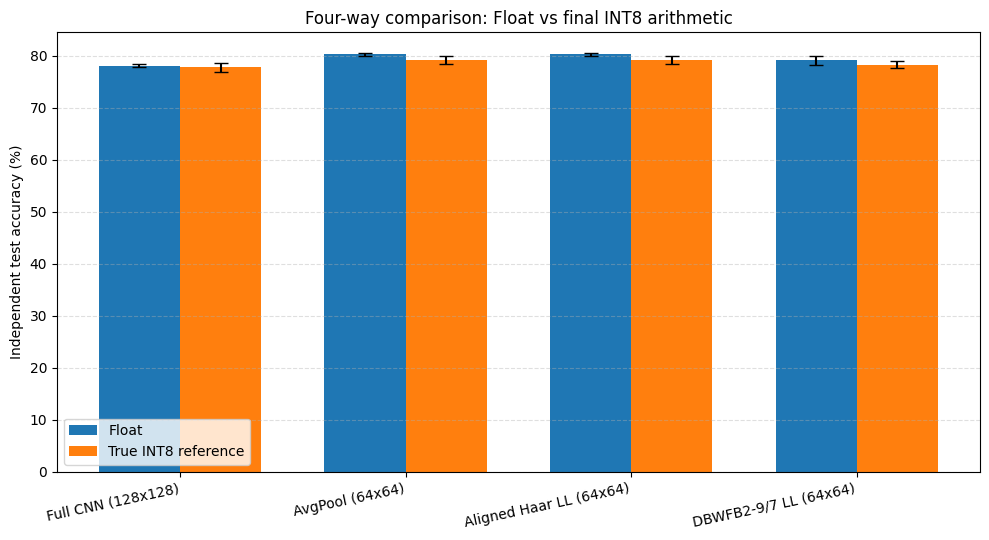

In [13]:
# 13. Figure: float vs true INT8 (matplotlib defaults)
x=np.arange(len(ARMS)); width=0.36
fig,ax=plt.subplots(figsize=(10,5.5))
ax.bar(x-width/2,summary['float_acc_mean'],width,yerr=summary['float_acc_std'],capsize=5,label='Float')
ax.bar(x+width/2,summary['int8_acc_mean'],width,yerr=summary['int8_acc_std'],capsize=5,label='True INT8 reference')
ax.set_xticks(x); ax.set_xticklabels([DISPLAY[a] for a in ARMS],rotation=12,ha='right')
ax.set_ylabel('Independent test accuracy (%)'); ax.set_title('Four-way comparison: Float vs final INT8 arithmetic')
ax.grid(axis='y',linestyle='--',alpha=0.4); ax.legend(); fig.tight_layout()
fig.savefig(RESULTS/'FINAL_float_vs_int8_ablation.png',dpi=300,bbox_inches='tight'); plt.show()

In [14]:
# 14. Paired effects, 95% CI, and prespecified TOST equivalence
def paired_stats(df,metric,a='dbwfb2',b='full',margin=EQUIV_MARGIN_PP,alpha=ALPHA):
    A=df[df.arm==a][['seed',metric]].rename(columns={metric:'a'})
    B=df[df.arm==b][['seed',metric]].rename(columns={metric:'b'})
    M=A.merge(B,on='seed').sort_values('seed'); d=(M.a-M.b).to_numpy(float); n=len(d)
    mean=float(d.mean()); sd=float(d.std(ddof=1)); se=sd/math.sqrt(n) if sd>0 else 0
    if sd>0:
        tc=stats.t.ppf(1-alpha/2,n-1); ci=(mean-tc*se,mean+tc*se)
        _,p2=stats.ttest_rel(M.a,M.b); dz=mean/sd
        tl=(mean+margin)/se; pl=1-stats.t.cdf(tl,n-1)
        tu=(mean-margin)/se; pu=stats.t.cdf(tu,n-1); eq=(pl<alpha and pu<alpha)
    else:
        ci=(mean,mean); p2=1.0 if mean==0 else 0.0; dz=0.0 if mean==0 else np.inf
        eq=abs(mean)<margin; pl=pu=0.0 if eq else 1.0
    return {'metric':metric,'comparison':f'{a} - {b}','n':n,'mean_difference_pp':mean,'ci95_low_pp':ci[0],'ci95_high_pp':ci[1],
            'paired_t_p':float(p2),'cohen_dz':float(dz),'tost_margin_pp':margin,'tost_p_lower':float(pl),'tost_p_upper':float(pu),'equivalence_established':bool(eq)}

stats_rows=[]
for metric in ['float_test_acc','int8_test_acc']:
    for other in ['full','avgpool','haar']:
        stats_rows.append(paired_stats(df_test,metric,'dbwfb2',other))
df_stats=pd.DataFrame(stats_rows); df_stats.to_csv(RESULTS/'FINAL_paired_statistics_and_TOST.csv',index=False)
print(df_stats.to_string(index=False))
for _,r in df_stats.iterrows():
    if r['comparison'] in ['dbwfb2 - avgpool','dbwfb2 - haar']:
        print(r['metric'],r['comparison'],'->', 'EQUIVALENCE ESTABLISHED' if r['equivalence_established'] else 'equivalence NOT established')

        metric       comparison  n  mean_difference_pp  ci95_low_pp  ci95_high_pp  paired_t_p  cohen_dz  tost_margin_pp  tost_p_lower  tost_p_upper  equivalence_established
float_test_acc    dbwfb2 - full  5             1.04375    -0.055313      2.142813    0.057779  1.179174             1.0      0.003342      0.541340                    False
float_test_acc dbwfb2 - avgpool  5            -1.13750    -2.375095      0.100095    0.063179 -1.141240             1.0      0.613439      0.004339                    False
float_test_acc    dbwfb2 - haar  5            -1.13750    -2.375095      0.100095    0.063179 -1.141240             1.0      0.613439      0.004339                    False
 int8_test_acc    dbwfb2 - full  5             0.52500    -0.990117      2.040117    0.390500  0.430246             1.0      0.024542      0.216592                    False
 int8_test_acc dbwfb2 - avgpool  5            -0.84375    -1.912391      0.224891    0.093467 -0.980361             1.0      0.352777  

In [15]:
# 15. Wilson interval for validation-selected DBWFB2 deployment model
def wilson(k,n,alpha=0.05):
    z=stats.norm.ppf(1-alpha/2); p=k/n; den=1+z*z/n
    center=(p+z*z/(2*n))/den; half=z*math.sqrt((p*(1-p)+z*z/(4*n))/n)/den
    return center-half,center+half

seed=selected_seed_by_arm['dbwfb2']; A=np.load(RESULTS/f'test_predictions_dbwfb2_seed{seed}.npz'); p=A['pred_int8']
k=int(np.sum(p==y_test)); lo,hi=wilson(k,len(y_test))
print('DBWFB2 deployment seed selected on validation:',seed)
print(f'Independent INT8 test accuracy: {k}/{len(y_test)} = {100*k/len(y_test):.2f}%')
print(f'95% Wilson CI: [{100*lo:.2f}%, {100*hi:.2f}%]')
print(classification_report(y_test,p,target_names=CLASS_NAMES,digits=4))

DBWFB2 deployment seed selected on validation: 42
Independent INT8 test accuracy: 2488/3200 = 77.75%
95% Wilson CI: [76.28%, 79.16%]
              precision    recall  f1-score   support

    airplane     0.6497    0.8300    0.7289       800
         car     0.8713    0.6937    0.7724       800
         dog     0.8718    0.9263    0.8982       800
        ship     0.7641    0.6600    0.7082       800

    accuracy                         0.7775      3200
   macro avg     0.7892    0.7775    0.7769      3200
weighted avg     0.7892    0.7775    0.7769      3200



In [16]:
# 16. Native-resolution 96x96 -> 48x48 Float control
#
# This remains a Float-only auxiliary native-resolution control.
# DBWFB2 uses the same trailing-replicate boundary/causal phase as the controller,
# with float coefficients.

native_rows = []

if RUN_NATIVE_96_48:
    for arm in ARMS:
        Xtr = get_preprocessed('train', arm, 'native', kind='float')
        Xv  = get_preprocessed('val', arm, 'native', kind='float')
        Xt  = get_preprocessed('test', arm, 'native', kind='float')

        for seed in SEEDS:
            print('Native', arm, seed)
            model, vm = train_one(
                Xtr, y_train, Xv, y_val, seed,
                MODELS/f'native_float_{arm}_seed{seed}.keras'
            )
            p = keras_pred(model, Xt)

            native_rows.append({
                'arm':arm,
                'seed':seed,
                'test_accuracy':100*accuracy_score(y_test,p),
                'macro_f1':100*f1_score(y_test,p,average='macro')
            })

    df_native = pd.DataFrame(native_rows)
    df_native.to_csv(
        RESULTS/'native_96_to_48_float_ablation.csv', index=False
    )
    print(
        df_native.groupby('arm')[['test_accuracy','macro_f1']]
        .agg(['mean','std']).round(3)
    )
else:
    print('Native experiment skipped.')


Cached ('train', 'full', 'native', 'float', 'STL10_HW_MATCHED_DEPLOYMENT_V1') (1600, 96, 96) float32
Cached ('val', 'full', 'native', 'float', 'STL10_HW_MATCHED_DEPLOYMENT_V1') (400, 96, 96) float32
Cached ('test', 'full', 'native', 'float', 'STL10_HW_MATCHED_DEPLOYMENT_V1') (3200, 96, 96) float32
Native full 42
Native full 100
Native full 123
Native full 777
Native full 2024
Cached ('train', 'avgpool', 'native', 'float', 'STL10_HW_MATCHED_DEPLOYMENT_V1') (1600, 48, 48) float32
Cached ('val', 'avgpool', 'native', 'float', 'STL10_HW_MATCHED_DEPLOYMENT_V1') (400, 48, 48) float32
Cached ('test', 'avgpool', 'native', 'float', 'STL10_HW_MATCHED_DEPLOYMENT_V1') (3200, 48, 48) float32
Native avgpool 42
Native avgpool 100
Native avgpool 123
Native avgpool 777
Native avgpool 2024
Cached ('train', 'haar', 'native', 'float', 'STL10_HW_MATCHED_DEPLOYMENT_V1') (1600, 48, 48) float32
Cached ('val', 'haar', 'native', 'float', 'STL10_HW_MATCHED_DEPLOYMENT_V1') (400, 48, 48) float32
Cached ('test', 'ha

In [17]:
# 17. DBWFB2 preprocessing localization on the untouched independent test set
#
# PRIMARY deployment path:
#   RTL structural integer preprocessing + trailing replicate.
#
# Diagnostic A:
#   same hardware boundary/phase but float coefficients.
#
# Diagnostic B:
#   legacy centered zero-extension Float convention retained only to quantify
#   sensitivity to the centered zero-extension convention.

seed = selected_seed_by_arm['dbwfb2']
pkg = load_pkg(PKGS/f'dbwfb2_seed{seed}')

X128f = resize_gray(X_test96, 128)
X128u = np.clip(np.rint(X128f), 0, 255).astype(np.uint8)

ll_primary = db_ll_hw_integer(X128u)
ll_same_boundary_float = db_ll_hw_float(X128f)
ll_legacy_zero = db_ll_legacy_zero_float(X128f)

q_primary, s_primary = quantize_input(ll_primary, SELECTED_INPUT_GAIN)
q_same, s_same = quantize_input(ll_same_boundary_float, SELECTED_INPUT_GAIN)
q_legacy, s_legacy = quantize_input(ll_legacy_zero, SELECTED_INPUT_GAIN)

p_primary, _ = int8_predict(pkg, q_primary)
p_same, _ = int8_predict(pkg, q_same)
p_legacy, _ = int8_predict(pkg, q_legacy)

bs = pd.DataFrame([
    {
        'path':'rtl_integer_trailing_replicate_PRIMARY',
        'accuracy':100*accuracy_score(y_test,p_primary),
        'input_saturation_fraction':s_primary,
        'agreement_vs_primary':1.0
    },
    {
        'path':'same_boundary_float_coefficients',
        'accuracy':100*accuracy_score(y_test,p_same),
        'input_saturation_fraction':s_same,
        'agreement_vs_primary':np.mean(p_same==p_primary)
    },
    {
        'path':'legacy_zero_boundary_float_DIAGNOSTIC',
        'accuracy':100*accuracy_score(y_test,p_legacy),
        'input_saturation_fraction':s_legacy,
        'agreement_vs_primary':np.mean(p_legacy==p_primary)
    }
])

print(bs.to_string(index=False))
print(
    'Float-vs-integer same-boundary LL MAE:',
    np.mean(np.abs(ll_same_boundary_float.astype(float)-ll_primary.astype(float)))
)
print(
    'Legacy-zero vs same-boundary Float LL MAE:',
    np.mean(np.abs(ll_legacy_zero.astype(float)-ll_same_boundary_float.astype(float)))
)

bs.to_csv(RESULTS/'DBWFB2_preprocessing_localization.csv', index=False)

# Critical consistency check: the main deployment preprocessing must reproduce
# the independently reconstructed primary tensor exactly.
Xdb_main = get_preprocessed('test','dbwfb2',kind='deploy')
assert np.array_equal(
    Xdb_main.astype(np.int16),
    ll_primary.astype(np.int16)
), 'Main DBWFB2 deployment preprocessing is not identical to the primary RTL structural model.'

print('PASS: main DBWFB2 software deployment preprocessing uses the hardware boundary/phase/integer model.')


                                  path  accuracy  input_saturation_fraction  agreement_vs_primary
rtl_integer_trailing_replicate_PRIMARY  77.75000                   0.003162              1.000000
      same_boundary_float_coefficients  77.59375                   0.004802              0.985000
 legacy_zero_boundary_float_DIAGNOSTIC  78.65625                   0.005091              0.928125
Float-vs-integer same-boundary LL MAE: 0.9352414028292111
Legacy-zero vs same-boundary Float LL MAE: 24.81423781846807
PASS: main DBWFB2 software deployment preprocessing uses the hardware boundary/phase/integer model.


In [18]:
# 18. Optional actual FPGA LL BRAM-dump comparison
#
# Place a (500,64,64) NumPy array at:
# dbwfb2_hw_matched_outputs/hardware_ll_board500.npy
#
# Do not claim preprocessing bit-exactness unless the PRIMARY reference matches.

dump = RESULTS/'hardware_ll_board500.npy'

if dump.exists():
    hw = np.load(dump)
    assert hw.shape == (500,64,64)

    refs = {
        'rtl_integer_trailing_replicate_PRIMARY': ll_primary[board_idx],
        'same_boundary_float_coefficients': ll_same_boundary_float[board_idx],
        'legacy_zero_boundary_float': ll_legacy_zero[board_idx],
    }

    rows = []
    for name, ref in refs.items():
        d = hw.astype(np.int64) - np.rint(ref).astype(np.int64)
        rows.append({
            'reference':name,
            'exact_fraction':float(np.mean(d==0)),
            'mae':float(np.mean(np.abs(d))),
            'max_abs_error':int(np.max(np.abs(d)))
        })

    hw_cmp = pd.DataFrame(rows)
    print(hw_cmp.to_string(index=False))
    hw_cmp.to_csv(RESULTS/'FPGA_LL_DUMP_COMPARISON.csv', index=False)

    primary = hw_cmp[
        hw_cmp.reference == 'rtl_integer_trailing_replicate_PRIMARY'
    ].iloc[0]

    if primary.exact_fraction == 1.0 and primary.max_abs_error == 0:
        print('PASS: FPGA LL dump is bit-exact to the primary software preprocessor.')
    else:
        print('NOT BIT-EXACT: do not claim preprocessing bit-exactness.')
else:
    print('No FPGA LL dump supplied:', dump)
    print('Boundary convention is matched by construction; bit-exact hardware proof remains unclaimed.')


No FPGA LL dump supplied: dbwfb2_hw_matched_outputs/hardware_ll_board500.npy
Boundary convention is matched by construction; bit-exact hardware proof remains unclaimed.


In [19]:
# 19. Export selected frozen hardware packages
def write_array(f,name,ctype,a,perline=16):
    x=np.asarray(a).flatten(order='C')
    f.write(f'const {ctype} {name}[{len(x)}] = {{\n    ')
    for i,v in enumerate(x):
        f.write(str(int(v)))
        if i!=len(x)-1:
            f.write(', ')
        if (i+1)%perline==0 and i!=len(x)-1:
            f.write('\n    ')
    f.write('\n};\n\n')

def export_weights(pkg,path):
    path=Path(path)
    path.parent.mkdir(parents=True,exist_ok=True)
    with open(path,'w') as f:
        f.write('// INT8 weights + INT32 fused biases\n')
        f.write(f'// protocol: {PROTOCOL_VERSION}\n')
        f.write('#pragma once\n#include <stdint.h>\n\n')
        write_array(f,'c1_w','int8_t',pkg['W1'])
        write_array(f,'c1_b','int32_t',pkg['B1'])
        write_array(f,'c2_w','int8_t',pkg['W2'])
        write_array(f,'c2_b','int32_t',pkg['B2'])
        write_array(f,'d_w','int8_t',pkg['W3'])
        write_array(f,'d_b','int32_t',pkg['B3'])

def storage_bytes(pkg):
    return int(sum(
        np.asarray(pkg[k]).nbytes
        for k in ['W1','B1','W2','B2','W3','B3']
    ))

man = []

for arm in ['avgpool','haar','dbwfb2']:
    seed = selected_seed_by_arm[arm]
    pkg = load_pkg(PKGS/f'{arm}_seed{seed}')
    dest = HWPKG/arm
    dest.mkdir(parents=True,exist_ok=True)

    export_weights(pkg,dest/'weights.h')

    with open(dest/'cnn_accel_shifts.txt','w') as f:
        f.write(f'#define C1_SHIFT {int(pkg["C1_SHIFT"])}\n')
        f.write(f'#define C2_SHIFT {int(pkg["C2_SHIFT"])}\n')

    m = {
        'protocol_version':PROTOCOL_VERSION,
        'arm':arm,
        'selected_seed_frozen_before_test':seed,
        'input_gain_frozen_before_test':SELECTED_INPUT_GAIN,
        'keras_parameter_count':5124,
        'deployed_tensor_storage_bytes':storage_bytes(pkg),
        'bias_dtype':'int32',
        'weight_dtype':'int8',
        'batchnorm_stored_separately':False,
        'C1_SHIFT':int(pkg['C1_SHIFT']),
        'C2_SHIFT':int(pkg['C2_SHIFT'])
    }

    if arm == 'dbwfb2':
        m['preprocessing_reference'] = (
            'RTL structural integer DBWFB2; trailing replicate; '
            '>>>10 each pass; even-index decimation'
        )

    with open(dest/'hardware_manifest.json','w') as f:
        json.dump(m,f,indent=2)

    man.append(m)

manifest_df = pd.DataFrame(man)
manifest_df.to_csv(RESULTS/'SELECTED_HARDWARE_PACKAGES.csv', index=False)
print(manifest_df.to_string(index=False))


                   protocol_version     arm  selected_seed_frozen_before_test  input_gain_frozen_before_test  keras_parameter_count  deployed_tensor_storage_bytes bias_dtype weight_dtype  batchnorm_stored_separately  C1_SHIFT  C2_SHIFT                                                                   preprocessing_reference
STL10_HW_MATCHED_DEPLOYMENT_V1 avgpool                                42                              1                   5124                           5088      int32         int8                        False         9         7                                                                                       NaN
STL10_HW_MATCHED_DEPLOYMENT_V1    haar                                42                              1                   5124                           5088      int32         int8                        False         9         7                                                                                       NaN
STL10_HW_MATCHED_DEPLOYMENT_V1  

In [20]:
# 20. Fixed 500 raw-image headers for same-flow hardware tests
#
# DBWFB2 expected_labels = PRIMARY hardware-matched software reference.
# DBWFB2 expected_labels_alt = same-boundary float-coefficient diagnostic only.

def write_raw_header(path,raw,labels,expected,alt=None,alt_description=None):
    with open(path,'w') as f:
        f.write('// GENERATED BY DBWFB2 STL-10 REPRODUCIBILITY NOTEBOOK\n')
        f.write(f'// protocol: {PROTOCOL_VERSION}\n')
        if alt_description:
            f.write(f'// expected_labels_alt: {alt_description}\n')
        f.write('#pragma once\n#include <stdint.h>\n\n')
        f.write('#define N_TEST_IMAGES 500\n')
        f.write('#define IMG_PIXELS 16384\n\n')

        f.write(
            'const uint8_t test_labels[N_TEST_IMAGES] = {' +
            ', '.join(map(str,labels.tolist())) + '};\n\n'
        )
        f.write(
            'const uint8_t expected_labels[N_TEST_IMAGES] = {' +
            ', '.join(map(str,expected.tolist())) + '};\n\n'
        )

        if alt is not None:
            f.write(
                'const uint8_t expected_labels_alt[N_TEST_IMAGES] = {' +
                ', '.join(map(str,alt.tolist())) + '};\n\n'
            )

        f.write('const uint8_t test_images_raw[N_TEST_IMAGES][IMG_PIXELS] = {\n')

        for i,img in enumerate(raw):
            f.write(
                f'  // board_order={i}, test_index={int(board_idx[i])}, '
                f'true={CLASS_NAMES[int(labels[i])]}\n  {{\n    '
            )
            flat=img.flatten()

            for j,v in enumerate(flat):
                f.write(str(int(v)))
                if j!=len(flat)-1:
                    f.write(', ')
                if (j+1)%16==0 and j!=len(flat)-1:
                    f.write('\n    ')

            f.write('\n  }'+(',\n' if i!=len(raw)-1 else '\n'))

        f.write('};\n')

raw = X128u[board_idx]
yb = y_test[board_idx]

for arm in ['avgpool','haar','dbwfb2']:
    seed = selected_seed_by_arm[arm]
    pkg = load_pkg(PKGS/f'{arm}_seed{seed}')

    Xdep = get_preprocessed('test',arm,kind='deploy')
    q,_ = quantize_input(Xdep[board_idx], SELECTED_INPUT_GAIN)
    exp,_ = int8_predict(pkg,q)

    alt = None
    alt_desc = None

    if arm == 'dbwfb2':
        q_alt,_ = quantize_input(
            ll_same_boundary_float[board_idx],
            SELECTED_INPUT_GAIN
        )
        alt,_ = int8_predict(pkg,q_alt)
        alt_desc = (
            'same trailing boundary/phase, float DBWFB2 coefficients; diagnostic only'
        )

    path = HWPKG/arm/f'test_vectors_raw_500_{arm}.h'
    write_raw_header(path,raw,yb,exp,alt,alt_desc)
    print('Wrote',path)


Wrote dbwfb2_hw_matched_outputs/hardware_packages/avgpool/test_vectors_raw_500_avgpool.h
Wrote dbwfb2_hw_matched_outputs/hardware_packages/haar/test_vectors_raw_500_haar.h
Wrote dbwfb2_hw_matched_outputs/hardware_packages/dbwfb2/test_vectors_raw_500_dbwfb2.h


In [21]:
# 21. All 3,200 packed CNN-only HLS vectors for selected DBWFB2 package
seed = selected_seed_by_arm['dbwfb2']
pkg = load_pkg(PKGS/f'dbwfb2_seed{seed}')

Xdb = get_preprocessed('test','dbwfb2',kind='deploy')
qdb,_ = quantize_input(Xdb,SELECTED_INPUT_GAIN)

# Must be identical to the independently reconstructed primary path.
assert np.array_equal(qdb, q_primary)

path = HWPKG/'dbwfb2'/'test_vectors_3200_cnn_only.h'

with open(path,'w') as f:
    f.write('// CNN-only packed vectors from hardware-matched DBWFB2 preprocessing\n')
    f.write(f'// protocol: {PROTOCOL_VERSION}\n')
    f.write('#pragma once\n#include <stdint.h>\n\n')
    f.write('#define N_TEST_IMAGES 3200\n\n')
    f.write(
        'const uint8_t test_labels[N_TEST_IMAGES] = {' +
        ', '.join(map(str,y_test.tolist())) + '};\n\n'
    )
    f.write('const uint32_t test_images[N_TEST_IMAGES][1024] = {\n')

    for n,img in enumerate(qdb):
        flat=img.astype(np.int16).flatten()
        words=[]

        for i in range(0,len(flat),4):
            p=[int(flat[i+j])&0xFF for j in range(4)]
            words.append((p[3]<<24)|(p[2]<<16)|(p[1]<<8)|p[0])

        f.write(
            f'  // test_index={n}, class={CLASS_NAMES[int(y_test[n])]}\n'
            '  {\n    '
        )

        for j,w in enumerate(words):
            f.write(f'0x{w:08X}')
            if j!=len(words)-1:
                f.write(', ')
            if (j+1)%8==0 and j!=len(words)-1:
                f.write('\n    ')

        f.write('\n  }'+(',\n' if n!=3199 else '\n'))

    f.write('};\n')

print('Wrote',path)


Wrote dbwfb2_hw_matched_outputs/hardware_packages/dbwfb2/test_vectors_3200_cnn_only.h


In [22]:
# 22. Diagnostic intermediate tensors for Python -> HLS -> hardware localization
seed=selected_seed_by_arm['dbwfb2']; pkg=load_pkg(PKGS/f'dbwfb2_seed{seed}')
diag_test_idx=board_idx[:N_DIAGNOSTIC]; qdiag=qdb[diag_test_idx]
pdiag,st,inter=int8_predict(pkg,qdiag,return_intermediates=True)
np.savez_compressed(RESULTS/'python_int8_diagnostic_tensors.npz',test_index=diag_test_idx,true_label=y_test[diag_test_idx],pred=pdiag,**inter)
pd.DataFrame({'diagnostic_order':np.arange(N_DIAGNOSTIC),'test_index':diag_test_idx,'true_label':y_test[diag_test_idx],'python_int8_pred':pdiag}).to_csv(RESULTS/'diagnostic_indices.csv',index=False)
print('Saved diagnostic tensors.',st)

def compare_npz(ref_path,other_path,keys=('input_q','acc1','fm1','fm2','acc2','fm3','fm4','gap','logits')):
    a=np.load(ref_path); b=np.load(other_path); rows=[]; first=None
    for k in keys:
        if k not in a.files or k not in b.files:
            rows.append({'tensor':k,'status':'missing','exact_fraction':np.nan,'max_abs':np.nan}); continue
        if a[k].shape!=b[k].shape:
            rows.append({'tensor':k,'status':f'shape {a[k].shape}!={b[k].shape}','exact_fraction':0.0,'max_abs':np.nan}); first=first or k; continue
        d=a[k].astype(np.int64)-b[k].astype(np.int64); ma=int(np.max(np.abs(d))) if d.size else 0
        rows.append({'tensor':k,'status':'ok','exact_fraction':np.mean(d==0),'max_abs':ma}); first=first or (k if ma else None)
    df=pd.DataFrame(rows); print(df.to_string(index=False)); print('FIRST DIVERGENCE:',first); return df,first

hls=RESULTS/'hls_int8_diagnostic_tensors.npz'
if hls.exists(): compare_npz(RESULTS/'python_int8_diagnostic_tensors.npz',hls)
else: print('Instrument C-sim and place:',hls)

Saved diagnostic tensors. {'conv1_positive_saturation_fraction': 0.0, 'conv2_positive_saturation_fraction': 0.0}
Instrument C-sim and place: dbwfb2_hw_matched_outputs/hls_int8_diagnostic_tensors.npz


In [23]:
# 23. Hardware-500 result parser + Wilson CI + same-subset per-class metrics
hwcsv=RESULTS/'hardware_predictions_500.csv'
if not hwcsv.exists():
    pd.DataFrame({'board_order':np.arange(500),'pred_hw':np.full(500,-1)}).to_csv(hwcsv,index=False)
    print('Created template:',hwcsv)
else:
    hw=pd.read_csv(hwcsv)
    if np.all(hw.pred_hw.to_numpy()>=0):
        m=board_manifest.merge(hw,on='board_order'); yb=m.true_label.to_numpy(int); ph=m.pred_hw.to_numpy(int)
        seed=selected_seed_by_arm['dbwfb2']; pkg=load_pkg(PKGS/f'dbwfb2_seed{seed}'); ps,_=int8_predict(pkg,qdb[board_idx])
        k=int(np.sum(yb==ph)); lo,hi=wilson(k,500)
        print(f'HW accuracy: {k}/500 = {100*k/500:.2f}%'); print(f'95% Wilson CI: [{100*lo:.2f}%, {100*hi:.2f}%]')
        print(f'Agreement with true INT8 software reference: {100*np.mean(ph==ps):.2f}%')
        print(classification_report(yb,ph,target_names=CLASS_NAMES,digits=4)); print('Confusion matrix:\n',confusion_matrix(yb,ph))
        d=m.loc[ph!=ps].copy(); d['pred_sw_int8']=ps[ph!=ps]; d.to_csv(RESULTS/'hardware_vs_int8_disagreements.csv',index=False)
        print('HW/SW deterministic disagreements:',len(d))
    else: print('Fill pred_hw with class IDs 0..3 after the ZedBoard run.')

Created template: dbwfb2_hw_matched_outputs/hardware_predictions_500.csv


In [24]:
# 24. Fresh hardware-result template
#
# IMPORTANT: software preprocessing/model packages have fixed in this hardware-matched
# protocol. Populate board metrics only from the matching captured run.
# Resource/timing/power values may be reused only after confirming the rebuilt
# hardware implementation is structurally identical and the routed reports support them.

columns = [
    'front_end',
    'front_end_LUT',
    'front_end_FF',
    'front_end_BRAM_tiles',
    'front_end_DSP',
    'system_LUT',
    'system_FF',
    'system_BRAM_tiles',
    'system_DSP',
    'postroute_WNS_ns',
    'postroute_TNS_ns',
    'tested_clock_MHz',
    'preprocess_total_ms',
    'CNN_start_to_done_ms',
    'end_to_end_ms',
    'total_onchip_power_W_estimate',
    'preprocess_hierarchy_dynamic_power_W_estimate',
    'board_accuracy_500_percent',
    'HW_SW_prediction_agreement_500_percent',
    'hardware_errors',
]

out_hw = RESULTS/'HARDWARE_RESULTS_TO_FILL.csv'

if not out_hw.exists():
    pd.DataFrame(
        [
            {'front_end':'DBWFB2'},
            {'front_end':'AvgPool'}
        ],
        columns=columns
    ).to_csv(out_hw,index=False)

print('Fresh hardware-results template:',out_hw)
print(pd.read_csv(out_hw).to_string(index=False))


Fresh hardware-results template: dbwfb2_hw_matched_outputs/HARDWARE_RESULTS_TO_FILL.csv
front_end  front_end_LUT  front_end_FF  front_end_BRAM_tiles  front_end_DSP  system_LUT  system_FF  system_BRAM_tiles  system_DSP  postroute_WNS_ns  postroute_TNS_ns  tested_clock_MHz  preprocess_total_ms  CNN_start_to_done_ms  end_to_end_ms  total_onchip_power_W_estimate  preprocess_hierarchy_dynamic_power_W_estimate  board_accuracy_500_percent  HW_SW_prediction_agreement_500_percent  hardware_errors
   DBWFB2            NaN           NaN                   NaN            NaN         NaN        NaN                NaN         NaN               NaN               NaN               NaN                  NaN                   NaN            NaN                            NaN                                            NaN                         NaN                                     NaN              NaN
  AvgPool            NaN           NaN                   NaN            NaN         NaN        NaN    

In [25]:
# Quantization-effect decomposition
# Float pipeline -> deployment-input Keras -> true INT8 arithmetic
#
# IMPORTANT:
#   deploy_keras -> true INT8 is the cleanest estimate of the CNN arithmetic
#   quantization penalty because it uses the same deployment-trained model.
#
#   float -> deployment_keras is NOT pure input-quantization error because
#   those models were trained separately. Report it as a configuration change.

quant_rows = []

for arm in ARMS:
    d = df_test[df_test["arm"] == arm].sort_values("seed").copy()

    # Per-seed paired changes
    float_acc = d["float_test_acc"].to_numpy(float)
    deploy_acc = d["deploy_keras_test_acc"].to_numpy(float)
    int8_acc = d["int8_test_acc"].to_numpy(float)

    # Positive value = accuracy loss
    float_to_deploy_loss = float_acc - deploy_acc
    deploy_to_int8_loss = deploy_acc - int8_acc
    float_to_int8_loss = float_acc - int8_acc

    quant_rows.append({
        "arm": arm,

        "float_acc_mean": np.mean(float_acc),
        "float_acc_std": np.std(float_acc, ddof=1),

        "deploy_input_keras_acc_mean": np.mean(deploy_acc),
        "deploy_input_keras_acc_std": np.std(deploy_acc, ddof=1),

        "true_int8_acc_mean": np.mean(int8_acc),
        "true_int8_acc_std": np.std(int8_acc, ddof=1),

        # This is not pure quantization because float/deploy models
        # are trained separately.
        "float_to_deploy_change_mean_pp": np.mean(deploy_acc - float_acc),
        "float_to_deploy_change_std_pp": np.std(
            deploy_acc - float_acc, ddof=1
        ),

        # CLEANEST quantization-arithmetic comparison:
        # same deployment-trained model, but Keras float arithmetic
        # versus final integer arithmetic.
        "cnn_integer_arithmetic_loss_mean_pp": np.mean(
            deploy_to_int8_loss
        ),
        "cnn_integer_arithmetic_loss_std_pp": np.std(
            deploy_to_int8_loss, ddof=1
        ),

        # Overall deployed-vs-float difference
        "total_float_to_int8_loss_mean_pp": np.mean(
            float_to_int8_loss
        ),
        "total_float_to_int8_loss_std_pp": np.std(
            float_to_int8_loss, ddof=1
        ),
    })

df_quant = pd.DataFrame(quant_rows)

# Make names easier to read in notebook output
if "DISPLAY" in globals():
    df_quant.insert(
        1,
        "method",
        [DISPLAY[a] for a in df_quant["arm"]]
    )

# Save final experiment summary
out_file = RESULTS / "FINAL_quantization_effect_decomposition.csv"
df_quant.to_csv(out_file, index=False)

# Compact paper-friendly display
show_cols = [
    "arm",
    "float_acc_mean",
    "deploy_input_keras_acc_mean",
    "true_int8_acc_mean",
    "cnn_integer_arithmetic_loss_mean_pp",
    "total_float_to_int8_loss_mean_pp",
]

print("\n=== Quantization / finite-precision decomposition ===\n")
print(df_quant[show_cols].round(3).to_string(index=False))

print("\nInterpretation:")
print("1. Float -> deployment-input Keras is NOT a pure quantization-only comparison,")
print("   because those models were trained separately.")
print("2. Deployment-input Keras -> true INT8 is the cleanest estimate of")
print("   accuracy loss introduced by integer CNN arithmetic.")
print("3. Float -> true INT8 is the complete end-to-end deployment difference.")
print("\nSaved:", out_file)


=== Quantization / finite-precision decomposition ===

    arm  float_acc_mean  deploy_input_keras_acc_mean  true_int8_acc_mean  cnn_integer_arithmetic_loss_mean_pp  total_float_to_int8_loss_mean_pp
   full          78.119                       79.631              77.788                                1.844                             0.331
avgpool          80.300                       81.556              79.156                                2.400                             1.144
   haar          80.300                       81.556              79.156                                2.400                             1.144
 dbwfb2          79.162                       80.481              78.312                                2.169                             0.850

Interpretation:
1. Float -> deployment-input Keras is NOT a pure quantization-only comparison,
   because those models were trained separately.
2. Deployment-input Keras -> true INT8 is the cleanest estimate of
   accuracy 

In [26]:
# 26. Generate selected Python true-INT8 expected predictions for HLS C-simulation
seed = selected_seed_by_arm['dbwfb2']

data = np.load(
    RESULTS / f'test_predictions_dbwfb2_seed{seed}.npz'
)
expected = data['pred_int8'].astype(np.uint8)

# Independent consistency check from the PRIMARY hardware-matched DBWFB2 input.
pkg = load_pkg(PKGS/f'dbwfb2_seed{seed}')
expected_check,_ = int8_predict(pkg, q_primary)
assert np.array_equal(expected, expected_check)

out = HWPKG/'dbwfb2'/'expected_int8_3200.h'

with open(out,'w') as f:
    f.write('// true-INT8 expected labels from hardware-matched DBWFB2 preprocessing\n')
    f.write(f'// protocol: {PROTOCOL_VERSION}\n')
    f.write('#pragma once\n#include <stdint.h>\n\n')
    f.write('#define N_EXPECTED_INT8 3200\n\n')
    f.write('const uint8_t expected_int8_labels[N_EXPECTED_INT8] = {\n    ')

    for i,v in enumerate(expected):
        f.write(str(int(v)))
        if i != len(expected)-1:
            f.write(', ')
        if (i+1)%32 == 0 and i != len(expected)-1:
            f.write('\n    ')

    f.write('\n};\n')

print('Saved:',out)
print('Number of predictions:',len(expected))
print('Selected DBWFB2 seed:',seed)
print(
    'Expected independent-test accuracy:',
    f'{np.sum(expected==y_test)}/{len(y_test)} = {100*np.mean(expected==y_test):.4f}%'
)


Saved: dbwfb2_hw_matched_outputs/hardware_packages/dbwfb2/expected_int8_3200.h
Number of predictions: 3200
Selected DBWFB2 seed: 42
Expected independent-test accuracy: 2488/3200 = 77.7500%


In [27]:
# 27. Reconstruct raw 128x128 input and primary/ALT DBWFB2 references
X128u = resize_gray_u8(X_test96, 128)

assert X128u.shape == (3200,128,128)
assert X128u.dtype == np.uint8

ll_primary = db_ll_hw_integer(X128u)
q_primary, q_primary_sat = quantize_input(
    ll_primary, SELECTED_INPUT_GAIN
)

# ALT: same boundary/phase, float coefficients.
X128f = resize_gray(X_test96, 128)
ll_alt_float = db_ll_hw_float(X128f)
q_alt_float, q_alt_sat = quantize_input(
    ll_alt_float, SELECTED_INPUT_GAIN
)

assert ll_primary.shape == (3200,64,64)
assert q_primary.shape == (3200,64,64)
assert q_primary.dtype == np.int8

print('X128u:',X128u.shape,X128u.dtype)
print('ll_primary:',ll_primary.shape,ll_primary.dtype)
print('q_primary:',q_primary.shape,q_primary.dtype)
print('Frozen gain:',SELECTED_INPUT_GAIN)
print('Primary saturation fraction:',q_primary_sat)
print('ALT same-boundary float saturation fraction:',q_alt_sat)


X128u: (3200, 128, 128) uint8
ll_primary: (3200, 64, 64) int16
q_primary: (3200, 64, 64) int8
Frozen gain: 1
Primary saturation fraction: 0.0031621551513671877
ALT same-boundary float saturation fraction: 0.004802017211914062


In [28]:
# 28. Generate full 3,200 raw DBWFB2 hardware headers as 4 x 800-image parts
#
# Accuracy, shifts, seed, and agreement are read from the selected package.

import zipfile

seed = selected_seed_by_arm['dbwfb2']
pkg = load_pkg(PKGS/f'dbwfb2_seed{seed}')

pred_file = RESULTS/f'test_predictions_dbwfb2_seed{seed}.npz'
assert pred_file.exists(), pred_file

saved = np.load(pred_file)
pred_primary = saved['pred_int8'].astype(np.uint8)
assert pred_primary.shape == (3200,)

pred_primary_check,_ = int8_predict(pkg,q_primary)
assert np.array_equal(
    pred_primary,pred_primary_check
), 'Saved PRIMARY predictions do not match fresh hardware-matched recomputation.'

pred_alt,_ = int8_predict(pkg,q_alt_float)
pred_alt = pred_alt.astype(np.uint8)

OUT = HWPKG/'dbwfb2'/'raw3200_parts'
OUT.mkdir(parents=True,exist_ok=True)

def write_raw_part_header(
    path, raw, labels, expected, expected_alt, global_start
):
    n=len(raw)

    with open(path,'w') as f:
        f.write('// GENERATED BY DBWFB2 STL-10 REPRODUCIBILITY NOTEBOOK\n')
        f.write(f'// protocol: {PROTOCOL_VERSION}\n')
        f.write('// expected_labels = PRIMARY RTL structural software reference\n')
        f.write('// expected_labels_alt = same-boundary float-coefficient diagnostic\n')
        f.write('#pragma once\n#include <stdint.h>\n\n')
        f.write(f'#define N_TEST_IMAGES {n}\n')
        f.write('#define IMG_PIXELS 16384\n')
        f.write(f'#define TEST_PART_START {global_start}\n\n')

        f.write('const uint8_t test_labels[N_TEST_IMAGES] = {')
        f.write(', '.join(map(str,labels.tolist())))
        f.write('};\n\n')

        f.write('const uint8_t expected_labels[N_TEST_IMAGES] = {')
        f.write(', '.join(map(str,expected.tolist())))
        f.write('};\n\n')

        f.write('const uint8_t expected_labels_alt[N_TEST_IMAGES] = {')
        f.write(', '.join(map(str,expected_alt.tolist())))
        f.write('};\n\n')

        f.write('const uint8_t test_images_raw[N_TEST_IMAGES][IMG_PIXELS] = {\n')

        for local_i,img in enumerate(raw):
            global_i=global_start+local_i
            true_class=CLASS_NAMES[int(labels[local_i])]

            f.write(
                f'  // local={local_i}, test_index={global_i}, true={true_class}\n'
                '  {\n    '
            )

            flat=img.reshape(-1)

            for j,v in enumerate(flat):
                f.write(str(int(v)))
                if j != len(flat)-1:
                    f.write(', ')
                if (j+1)%16 == 0 and j != len(flat)-1:
                    f.write('\n    ')

            f.write('\n  }')
            if local_i != n-1:
                f.write(',')
            f.write('\n')

        f.write('};\n')

PART_SIZE = 800
generated_files=[]
part_manifest=[]

for part in range(4):
    start=part*PART_SIZE
    end=start+PART_SIZE
    path=OUT/f'test_vectors_raw_3200_part{part}_dbwfb2.h'

    write_raw_part_header(
        path=path,
        raw=X128u[start:end],
        labels=y_test[start:end],
        expected=pred_primary[start:end],
        expected_alt=pred_alt[start:end],
        global_start=start
    )

    generated_files.append(path)

    part_manifest.append({
        'part':part,
        'start':start,
        'end_exclusive':end,
        'primary_correct':int(np.sum(
            pred_primary[start:end]==y_test[start:end]
        )),
        'alt_correct':int(np.sum(
            pred_alt[start:end]==y_test[start:end]
        )),
        'primary_alt_agreement':int(np.sum(
            pred_primary[start:end]==pred_alt[start:end]
        ))
    })

    print(f'part{part}: {start}..{end-1} -> {path.name}')

pd.DataFrame(part_manifest).to_csv(
    OUT/'raw3200_parts_manifest.csv',index=False
)

zip_path=OUT/'DBWFB2_RAW_3200_4x800_HEADERS_SW_HW_MATCHED.zip'

with zipfile.ZipFile(
    zip_path,'w',compression=zipfile.ZIP_DEFLATED
) as z:
    for p in generated_files:
        z.write(p,arcname=p.name)
    z.write(
        OUT/'raw3200_parts_manifest.csv',
        arcname='raw3200_parts_manifest.csv'
    )

print('Created:',zip_path)
print('Frozen deployment seed:',seed)
print('Frozen deployment gain:',SELECTED_INPUT_GAIN)
print('Selected shifts from fresh package:',int(pkg['C1_SHIFT']),int(pkg['C2_SHIFT']))
print(
    'PRIMARY expected accuracy:',
    f'{np.sum(pred_primary==y_test)}/3200 = {100*np.mean(pred_primary==y_test):.4f}%'
)
print(
    'ALT expected accuracy:',
    f'{np.sum(pred_alt==y_test)}/3200 = {100*np.mean(pred_alt==y_test):.4f}%'
)
print(
    'PRIMARY/ALT agreement:',
    f'{np.sum(pred_primary==pred_alt)}/3200 = {100*np.mean(pred_primary==pred_alt):.4f}%'
)


part0: 0..799 -> test_vectors_raw_3200_part0_dbwfb2.h
part1: 800..1599 -> test_vectors_raw_3200_part1_dbwfb2.h
part2: 1600..2399 -> test_vectors_raw_3200_part2_dbwfb2.h
part3: 2400..3199 -> test_vectors_raw_3200_part3_dbwfb2.h
Created: dbwfb2_hw_matched_outputs/hardware_packages/dbwfb2/raw3200_parts/DBWFB2_RAW_3200_4x800_HEADERS_SW_HW_MATCHED.zip
Frozen deployment seed: 42
Frozen deployment gain: 1
Selected shifts from fresh package: 9 8
PRIMARY expected accuracy: 2488/3200 = 77.7500%
ALT expected accuracy: 2483/3200 = 77.5938%
PRIMARY/ALT agreement: 3152/3200 = 98.5000%


In [29]:
# 29. Final run manifest and upload bundle
import hashlib
import zipfile

def sha256_file(path, chunk=1<<20):
    h=hashlib.sha256()
    with open(path,'rb') as f:
        while True:
            b=f.read(chunk)
            if not b:
                break
            h.update(b)
    return h.hexdigest()

selected_summary = {}

for arm in ARMS:
    seed = selected_seed_by_arm[arm]
    pkg = load_pkg(PKGS/f'{arm}_seed{seed}')
    pred = np.load(
        RESULTS/f'test_predictions_{arm}_seed{seed}.npz'
    )['pred_int8']

    selected_summary[arm] = {
        'seed':int(seed),
        'gain':int(SELECTED_INPUT_GAIN),
        'C1_SHIFT':int(pkg['C1_SHIFT']),
        'C2_SHIFT':int(pkg['C2_SHIFT']),
        'test_correct':int(np.sum(pred==y_test)),
        'test_total':int(len(y_test)),
        'test_accuracy_percent':float(100*np.mean(pred==y_test))
    }

run_manifest = {
    'protocol_version':PROTOCOL_VERSION,
    'software_hardware_boundary_rule':
        'DBWFB2 trailing-edge replicate in both software and FPGA',
    'dbwfb2_float_reference':
        'same causal phase/boundary as hardware; float coefficients',
    'dbwfb2_primary_deployment_reference':
        'RTL structural integer model; >>>10 each pass; even-index decimation',
    'legacy_zero_boundary_status':
        'diagnostic comparator only; not used for primary training/deployment',
    'frozen_gain':int(SELECTED_INPUT_GAIN),
    'frozen_deployment_seed_by_arm':selected_seed_by_arm,
    'selected':selected_summary,
    'hardware_bit_exactness_claim':
        'only if actual FPGA LL dump comparison passes exact equality',
    'hardware_results_status':
        'fresh board/HLS/Vivado outputs must be supplied for the fresh packages'
}

manifest_path=RESULTS/'FINAL_RUN_MANIFEST.json'
with open(manifest_path,'w') as f:
    json.dump(run_manifest,f,indent=2)

key_files = [
    RESULTS/'split_manifest.json',
    RESULTS/'FROZEN_DECISIONS_BEFORE_TEST.json',
    RESULTS/'gain_ablation_validation_only.csv',
    RESULTS/'validation_results_all_arms.csv',
    RESULTS/'FINAL_test_results_all_arms.csv',
    RESULTS/'FINAL_summary_float_vs_true_int8.csv',
    RESULTS/'FINAL_paired_statistics_and_TOST.csv',
    RESULTS/'DBWFB2_preprocessing_localization.csv',
    RESULTS/'SELECTED_HARDWARE_PACKAGES.csv',
    RESULTS/'FINAL_RUN_MANIFEST.json',
    RESULTS/'HARDWARE_RESULTS_TO_FILL.csv'
]

hash_rows=[]
for p in key_files:
    if p.exists():
        hash_rows.append({
            'relative_path':str(p.relative_to(RESULTS)),
            'sha256':sha256_file(p),
            'bytes':p.stat().st_size
        })

hash_df=pd.DataFrame(hash_rows)
hash_df.to_csv(RESULTS/'KEY_ARTIFACT_SHA256.csv',index=False)

bundle=RESULTS/'UPLOAD_BACK_FOR_FINAL_VERIFICATION.zip'

with zipfile.ZipFile(
    bundle,'w',compression=zipfile.ZIP_DEFLATED
) as z:
    for p in key_files + [RESULTS/'KEY_ARTIFACT_SHA256.csv']:
        if p.exists():
            z.write(p,arcname=str(p.relative_to(RESULTS)))

    for arm in ['avgpool','haar','dbwfb2']:
        for name in [
            'weights.h',
            'cnn_accel_shifts.txt',
            'hardware_manifest.json',
            f'test_vectors_raw_500_{arm}.h'
        ]:
            p=HWPKG/arm/name
            if p.exists():
                z.write(p,arcname=str(p.relative_to(RESULTS)))

    p=HWPKG/'dbwfb2'/'expected_int8_3200.h'
    if p.exists():
        z.write(p,arcname=str(p.relative_to(RESULTS)))

    p=HWPKG/'dbwfb2'/'test_vectors_3200_cnn_only.h'
    if p.exists():
        z.write(p,arcname=str(p.relative_to(RESULTS)))

print(json.dumps(run_manifest,indent=2))
print('Created:',bundle)
print(
    'Separate raw-3200 ZIP:',
    HWPKG/'dbwfb2'/'raw3200_parts'/
    'DBWFB2_RAW_3200_4x800_HEADERS_SW_HW_MATCHED.zip'
)


{
  "protocol_version": "STL10_HW_MATCHED_DEPLOYMENT_V1",
  "software_hardware_boundary_rule": "DBWFB2 trailing-edge replicate in both software and FPGA",
  "dbwfb2_float_reference": "same causal phase/boundary as hardware; float coefficients",
  "dbwfb2_primary_deployment_reference": "RTL structural integer model; >>>10 each pass; even-index decimation",
  "legacy_zero_boundary_status": "diagnostic comparator only; not used for primary training/deployment",
  "frozen_gain": 1,
  "frozen_deployment_seed_by_arm": {
    "full": 777,
    "avgpool": 42,
    "haar": 42,
    "dbwfb2": 42
  },
  "selected": {
    "full": {
      "seed": 777,
      "gain": 1,
      "C1_SHIFT": 8,
      "C2_SHIFT": 8,
      "test_correct": 2520,
      "test_total": 3200,
      "test_accuracy_percent": 78.75
    },
    "avgpool": {
      "seed": 42,
      "gain": 1,
      "C1_SHIFT": 9,
      "C2_SHIFT": 7,
      "test_correct": 2558,
      "test_total": 3200,
      "test_accuracy_percent": 79.9375
    },
    "h

In [30]:
# 30. Unattended final auto-download (Google Colab)
#
# Run the notebook with Runtime -> Run all. After all results are finished,
# this cell packages the two final ZIP artifacts into ONE ZIP and triggers
# a single browser download. A single download is more reliable than asking
# the browser to allow multiple automatic downloads.

import zipfile
from pathlib import Path

final_bundle = RESULTS / 'UPLOAD_BACK_FOR_FINAL_VERIFICATION.zip'
raw3200_bundle = (
    HWPKG / 'dbwfb2' / 'raw3200_parts' /
    'DBWFB2_RAW_3200_4x800_HEADERS_SW_HW_MATCHED.zip'
)
auto_download_zip = RESULTS / 'ALL_RESULTS_AUTO_DOWNLOAD.zip'

artifacts_to_pack = [final_bundle, raw3200_bundle]
missing = [p for p in artifacts_to_pack if not p.exists()]
if missing:
    raise FileNotFoundError(
        'Cannot auto-download because these expected result ZIP(s) are missing: '
        + ', '.join(str(p) for p in missing)
    )

# The inputs are already ZIP-compressed, so store them without trying to
# recompress them. This is faster and avoids wasting CPU at the very end.
with zipfile.ZipFile(auto_download_zip, 'w', compression=zipfile.ZIP_STORED) as z:
    z.write(final_bundle, arcname=final_bundle.name)
    z.write(raw3200_bundle, arcname=raw3200_bundle.name)

print('Created unattended download package:', auto_download_zip.resolve())
print('Size (MiB):', round(auto_download_zip.stat().st_size / (1024**2), 2))
print('Starting browser download now...')

try:
    from google.colab import files
    files.download(str(auto_download_zip))
except ImportError:
    print(
        'Not running inside Google Colab, so browser auto-download was skipped. '
        f'The ZIP is saved at: {auto_download_zip.resolve()}'
    )


Created unattended download package: /content/dbwfb2_hw_matched_outputs/ALL_RESULTS_AUTO_DOWNLOAD.zip
Size (MiB): 88.0
Starting browser download now...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Software–FPGA numerical consistency analysis

This section consolidates the frozen diagnostic evidence without retraining or changing the deployment package. The primary software path and the implemented FPGA stream convention are retained as distinct preprocessing definitions. Physical tracing covers RAW through the packed CNN input; CNN-internal checkpoints are compared between Python true-INT8 and HLS C-simulation.


In [31]:
# Frozen software–FPGA numerical consistency evidence (no retraining)
from pathlib import Path
import json

def locate_repository():
    candidates = [Path.cwd(), Path.cwd().parent]
    for p in candidates:
        if (p / "results" / "dbwfb2_fpga_full3200_metrics.json").exists():
            return p
    raise FileNotFoundError("Run this cell from the repository root or its notebooks directory.")

repo = locate_repository()
fpga = json.loads((repo / "results" / "dbwfb2_fpga_full3200_metrics.json").read_text())
hls = json.loads((repo / "results" / "dbwfb2_hls_verification.json").read_text())
major5 = json.loads((repo / "diagnostics" / "cnn_numerical_consistency" / "operation_audit.json").read_text())

assert fpga["correct"] == 2497 and fpga["images_completed"] == 3200
assert fpga["python_reference_matches"] == 3006 and fpga["hardware_errors"] == 0
assert hls["correct"] == 2488 and hls["python_reference_matches"] == 3200

summary = {'frozen_configuration': {'seed': 42, 'input_gain': 1, 'C1_SHIFT': 9, 'C2_SHIFT': 8}, 'selected_python_primary': {'correct': 2488, 'total': 3200, 'accuracy_percent': 77.75}, 'hls_csimulation': {'correct': 2488, 'total': 3200, 'accuracy_percent': 77.75, 'python_hls_prediction_agreement': '3200/3200'}, 'physical_fpga': {'correct': 2497, 'total': 3200, 'accuracy_percent': 78.03125, 'python_primary_agreement': '3006/3200', 'hardware_errors': 0}, 'hardware_equivalent_software': {'correct': 2497, 'total': 3200, 'fpga_prediction_agreement': '3200/3200'}, 'first_divergence_relative_to_primary': 'ROW / Matrix_L', 'diagnostic_preprocessing_exact': {'RAW': '163840/163840', 'ROW': '81920/81920', 'LL': '40960/40960', 'CNN_INPUT': '40960/40960'}, 'python_hls_intermediate_mismatches': 0, 'gap_pre_shift_mismatches': 0, 'gap_post_shift_mismatches': 0, 'gap_channel_comparisons': 640, 'board500': {'python_primary_correct': 408, 'fpga_correct': 404, 'fpga_accuracy_percent': 80.8, 'hardware_equivalent_fpga_agreement': '500/500'}}
summary


{
  "frozen_configuration": {
    "seed": 42,
    "input_gain": 1,
    "C1_SHIFT": 9,
    "C2_SHIFT": 8
  },
  "selected_python_primary": {
    "correct": 2488,
    "total": 3200,
    "accuracy_percent": 77.75
  },
  "hls_csimulation": {
    "correct": 2488,
    "total": 3200,
    "accuracy_percent": 77.75,
    "python_hls_prediction_agreement": "3200/3200"
  },
  "physical_fpga": {
    "correct": 2497,
    "total": 3200,
    "accuracy_percent": 78.03125,
    "python_primary_agreement": "3006/3200",
    "hardware_errors": 0
  },
  "hardware_equivalent_software": {
    "correct": 2497,
    "total": 3200,
    "fpga_prediction_agreement": "3200/3200"
  },
  "first_divergence_relative_to_primary": "ROW / Matrix_L",
  "diagnostic_preprocessing_exact": {
    "RAW": "163840/163840",
    "ROW": "81920/81920",
    "LL": "40960/40960",
    "CNN_INPUT": "40960/40960"
  },
  "python_hls_intermediate_mismatches": 0,
  "gap_pre_shift_mismatches": 0,
  "gap_post_shift_mismatches": 0,
  "gap_channel_c

### Interpretation

The first primary-reference difference is at ROW / Matrix_L. Once the implemented stream alignment, retained transaction state, trailing replication, integer accumulation, arithmetic shifts, clipping and packing are modeled, all 3,200 FPGA predictions are reproduced. Python and HLS CNN checkpoints, including the 32-channel GAP sums and `>>8` outputs, are exact on the diagnostic set.
